# Forward pass de `MDEQNet` — dos diagramas

Este notebook dibuja (con `matplotlib`, sin dependencias extra) dos versiones del forward pass definido en
`mmdet/models/backbones/mdeq.py` (método `MDEQNet.forward`, `x_` es el primer argumento):

1. **`x_` es un tensor (imagen sola)** — el camino que toma el primer frame de la ventana de contexto: arranca en cero (`flag=True`).
2. **`x_` es una lista (modo streaming)** — el camino que toman todos los frames siguientes: reutiliza el `z` del paso anterior como warm-start (`flag=False`).

La idea es visualizar, lado a lado, **qué información entra**, **qué se recalcula siempre** (`x_list`, la inyección de la imagen) y **qué se reutiliza según el caso** (`z_list`, el estado del solver).

> Nota: este notebook no fue ejecutado todavía en este entorno (no tengo `matplotlib` instalado acá). `matplotlib` ya es una dependencia del proyecto (se importa directamente en `mdeq.py`), así que debería estar disponible en tu conda env `streamdeq` una vez que lo armes siguiendo el `README.md`. Corré las celdas en orden; si algún texto se sale de una caja, es solo un ajuste de `fontsize`/tamaño de figura, avisame y lo afinamos juntos.

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def draw_box(ax, x, y, w, h, text, facecolor="#E8F0FE", edgecolor="#4472C4",
             fontsize=8.3, fontweight="normal"):
    """Dibuja una caja redondeada centrada en (x, y) con texto monospace adentro."""
    box = FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        linewidth=1.4, edgecolor=edgecolor, facecolor=facecolor,
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize,
            fontweight=fontweight, family="monospace")
    return box


def draw_arrow(ax, xy_from, xy_to, label=None, color="black", label_dx=0.15):
    """Dibuja una flecha entre dos puntos, con etiqueta opcional."""
    arrow = FancyArrowPatch(
        xy_from, xy_to, arrowstyle="-|>", mutation_scale=16,
        linewidth=1.4, color=color,
    )
    ax.add_patch(arrow)
    if label:
        mx, my = (xy_from[0] + xy_to[0]) / 2, (xy_from[1] + xy_to[1]) / 2
        ax.text(mx + label_dx, my, label, ha="left", va="center",
                fontsize=8, color=color, style="italic")


def new_canvas(figsize=(11, 12), xlim=(0, 12), ylim=(0, 15)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axis("off")
    return fig, ax

## Diagrama 1 — `x_` es una imagen (`flag = True`, cold start)

Corresponde al primer paso de la cadena de warm-start (por ejemplo, el frame `t-2` en el ejemplo "2f" que vimos antes): no hay ningún `z` previo disponible, así que `z_list` arranca en cero.

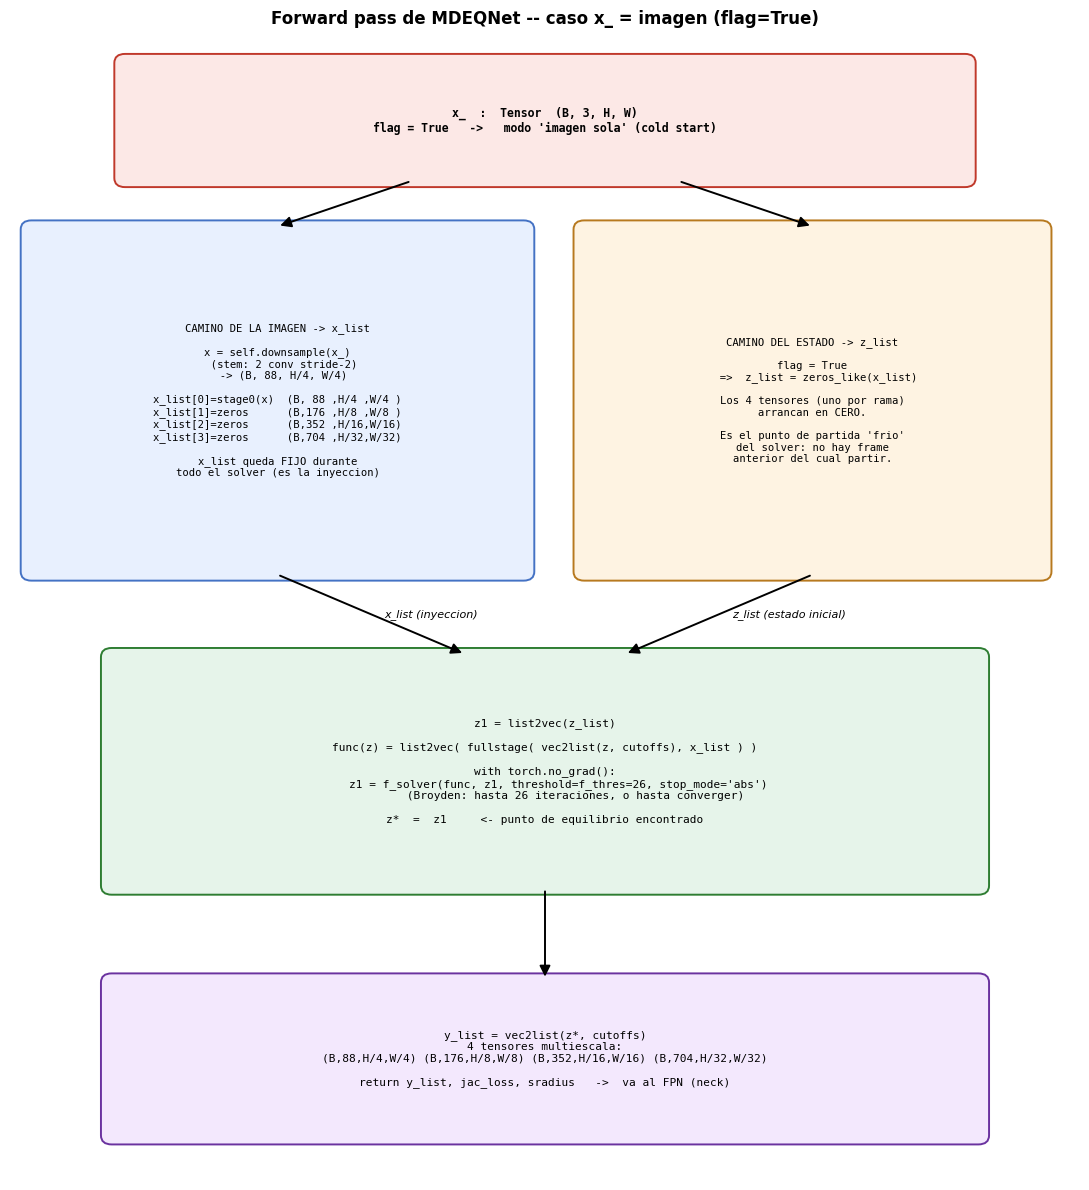

In [3]:
fig, ax = new_canvas()

# Nivel 1: entrada
draw_box(ax, 6, 14, 9.5, 1.6,
    "x_  :  Tensor  (B, 3, H, W)\n"
    "flag = True   ->   modo 'imagen sola' (cold start)",
    facecolor="#FCE8E6", edgecolor="#C0392B", fontweight="bold")

# Nivel 2a: camino de la imagen (izquierda) -> x_list
draw_box(ax, 3, 10.3, 5.6, 4.6,
    "CAMINO DE LA IMAGEN -> x_list\n\n"
    "x = self.downsample(x_)\n"
    "  (stem: 2 conv stride-2)\n"
    "  -> (B, 88, H/4, W/4)\n\n"
    "x_list[0]=stage0(x)  (B, 88 ,H/4 ,W/4 )\n"
    "x_list[1]=zeros      (B,176 ,H/8 ,W/8 )\n"
    "x_list[2]=zeros      (B,352 ,H/16,W/16)\n"
    "x_list[3]=zeros      (B,704 ,H/32,W/32)\n\n"
    "x_list queda FIJO durante\n"
    "todo el solver (es la inyeccion)",
    facecolor="#E8F0FE", edgecolor="#4472C4", fontsize=7.6)

# Nivel 2b: camino del estado (derecha) -> z_list
draw_box(ax, 9, 10.3, 5.2, 4.6,
    "CAMINO DEL ESTADO -> z_list\n\n"
    "flag = True\n"
    "  =>  z_list = zeros_like(x_list)\n\n"
    "Los 4 tensores (uno por rama)\n"
    "arrancan en CERO.\n\n"
    "Es el punto de partida 'frio'\n"
    "del solver: no hay frame\n"
    "anterior del cual partir.",
    facecolor="#FEF3E2", edgecolor="#B7791F", fontsize=7.6)

# Nivel 3: solver de punto fijo
draw_box(ax, 6, 5.4, 9.8, 3.1,
    "z1 = list2vec(z_list)\n\n"
    "func(z) = list2vec( fullstage( vec2list(z, cutoffs), x_list ) )\n\n"
    "with torch.no_grad():\n"
    "    z1 = f_solver(func, z1, threshold=f_thres=26, stop_mode='abs')\n"
    "         (Broyden: hasta 26 iteraciones, o hasta converger)\n\n"
    "z*  =  z1     <- punto de equilibrio encontrado",
    facecolor="#E6F4EA", edgecolor="#2E7D32", fontsize=8)

# Nivel 4: salida
draw_box(ax, 6, 1.6, 9.8, 2.1,
    "y_list = vec2list(z*, cutoffs)\n"
    "4 tensores multiescala:\n"
    "(B,88,H/4,W/4) (B,176,H/8,W/8) (B,352,H/16,W/16) (B,704,H/32,W/32)\n\n"
    "return y_list, jac_loss, sradius   ->  va al FPN (neck)",
    facecolor="#F3E8FD", edgecolor="#6A329F", fontsize=8)

draw_arrow(ax, (4.5, 13.2), (3, 12.6))
draw_arrow(ax, (7.5, 13.2), (9, 12.6))
draw_arrow(ax, (3, 8.0), (5.1, 6.95), label="x_list (inyeccion)")
draw_arrow(ax, (9, 8.0), (6.9, 6.95), label="z_list (estado inicial)")
draw_arrow(ax, (6, 3.85), (6, 2.65))

ax.set_title("Forward pass de MDEQNet -- caso x_ = imagen (flag=True)",
             fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("forward_pass_imagen.png", dpi=150, bbox_inches="tight")
plt.show()

## Diagrama 2 — `x_` es una lista (`flag = False`, modo streaming)

Corresponde a cualquier paso de la cadena que **no** es el primero (por ejemplo, `t-1` o `t` en el ejemplo "2f"). `x_` llega como `[imagen_actual] + z_anterior`. Compará este diagrama con el anterior: el camino de la imagen (izquierda) es idéntico; lo único que cambia es de dónde sale `z_list` (derecha).

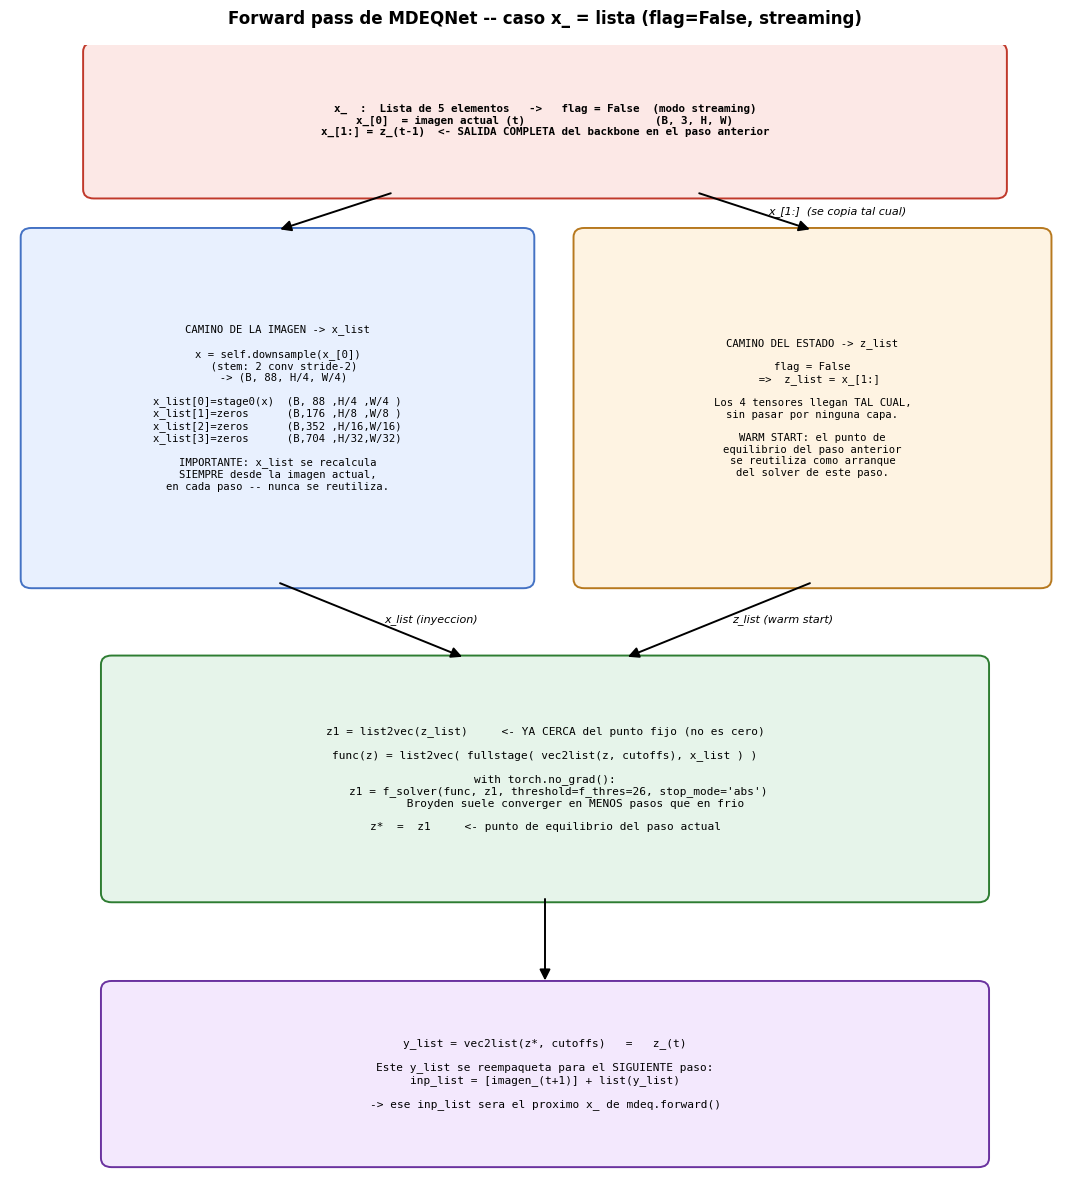

In [4]:
fig, ax = new_canvas()

# Nivel 1: entrada
draw_box(ax, 6, 14, 10.2, 1.9,
    "x_  :  Lista de 5 elementos   ->   flag = False  (modo streaming)\n"
    "x_[0]  = imagen actual (t)                    (B, 3, H, W)\n"
    "x_[1:] = z_(t-1)  <- SALIDA COMPLETA del backbone en el paso anterior",
    facecolor="#FCE8E6", edgecolor="#C0392B", fontweight="bold", fontsize=7.8)

# Nivel 2a: camino de la imagen (izquierda) -> x_list -- IGUAL que en el diagrama 1
draw_box(ax, 3, 10.2, 5.6, 4.6,
    "CAMINO DE LA IMAGEN -> x_list\n\n"
    "x = self.downsample(x_[0])\n"
    "  (stem: 2 conv stride-2)\n"
    "  -> (B, 88, H/4, W/4)\n\n"
    "x_list[0]=stage0(x)  (B, 88 ,H/4 ,W/4 )\n"
    "x_list[1]=zeros      (B,176 ,H/8 ,W/8 )\n"
    "x_list[2]=zeros      (B,352 ,H/16,W/16)\n"
    "x_list[3]=zeros      (B,704 ,H/32,W/32)\n\n"
    "IMPORTANTE: x_list se recalcula\n"
    "SIEMPRE desde la imagen actual,\n"
    "en cada paso -- nunca se reutiliza.",
    facecolor="#E8F0FE", edgecolor="#4472C4", fontsize=7.6)

# Nivel 2b: camino del estado (derecha) -> z_list -- ACA esta la diferencia clave
draw_box(ax, 9, 10.2, 5.2, 4.6,
    "CAMINO DEL ESTADO -> z_list\n\n"
    "flag = False\n"
    "  =>  z_list = x_[1:]\n\n"
    "Los 4 tensores llegan TAL CUAL,\n"
    "sin pasar por ninguna capa.\n\n"
    "WARM START: el punto de\n"
    "equilibrio del paso anterior\n"
    "se reutiliza como arranque\n"
    "del solver de este paso.",
    facecolor="#FEF3E2", edgecolor="#B7791F", fontsize=7.6)

# Nivel 3: solver de punto fijo
draw_box(ax, 6, 5.3, 9.8, 3.1,
    "z1 = list2vec(z_list)     <- YA CERCA del punto fijo (no es cero)\n\n"
    "func(z) = list2vec( fullstage( vec2list(z, cutoffs), x_list ) )\n\n"
    "with torch.no_grad():\n"
    "    z1 = f_solver(func, z1, threshold=f_thres=26, stop_mode='abs')\n"
    "         Broyden suele converger en MENOS pasos que en frio\n\n"
    "z*  =  z1     <- punto de equilibrio del paso actual",
    facecolor="#E6F4EA", edgecolor="#2E7D32", fontsize=8)

# Nivel 4: salida, con el enganche hacia el SIGUIENTE paso
draw_box(ax, 6, 1.4, 9.8, 2.3,
    "y_list = vec2list(z*, cutoffs)   =   z_(t)\n\n"
    "Este y_list se reempaqueta para el SIGUIENTE paso:\n"
    "inp_list = [imagen_(t+1)] + list(y_list)\n\n"
    "-> ese inp_list sera el proximo x_ de mdeq.forward()",
    facecolor="#F3E8FD", edgecolor="#6A329F", fontsize=8)

draw_arrow(ax, (4.3, 13.05), (3, 12.55))
draw_arrow(ax, (7.7, 13.05), (9, 12.55), label="x_[1:]  (se copia tal cual)")
draw_arrow(ax, (3, 7.9), (5.1, 6.9), label="x_list (inyeccion)")
draw_arrow(ax, (9, 7.9), (6.9, 6.9), label="z_list (warm start)")
draw_arrow(ax, (6, 3.75), (6, 2.6))

ax.set_title("Forward pass de MDEQNet -- caso x_ = lista (flag=False, streaming)",
             fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("forward_pass_streaming.png", dpi=150, bbox_inches="tight")
plt.show()

## Resumen: qué cambia entre los dos casos

| | `x_` = imagen (`flag=True`) | `x_` = lista (`flag=False`) |
|---|---|---|
| **Entrada** | 1 tensor `(B,3,H,W)` | 5 elementos: `[imagen, z0, z1, z2, z3]` |
| **`x_list` (inyección)** | calculado desde `x_` | calculado desde `x_[0]` — **misma lógica siempre** |
| **`z_list` (estado inicial)** | `zeros_like(x_list)` | `x_[1:]`, tal cual llegó |
| **Punto de partida del solver** | cero ("frío") | equilibrio del paso anterior ("tibio") |
| **Iteraciones de Broyden típicas** | más (hasta el tope `f_thres`) | menos (ya está cerca del nuevo punto fijo) |
| **Cuándo ocurre** | primer frame de la ventana de contexto | todos los pasos siguientes |

La única diferencia real en el código está en **de dónde sale `z_list`** ([mdeq.py:439-460](../mmdet/models/backbones/mdeq.py#L439-L460)); todo lo demás (`x_list`, `func`, el solver, `vec2list` final) es exactamente el mismo camino en los dos casos. Eso es lo que hace que StreamDEQ sea, en el fondo, el mismo modelo MDEQ — la única diferencia es *desde dónde* arranca el solver de punto fijo en cada frame.